# Pr-YBCO version Fit modes

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
from importlib import reload
import P2_alris_one_third_functions as P2_alris_one_third_functions
reload(P2_alris_one_third_functions)
from P2_alris_one_third_functions import shift_atoms, transform_list_hkl_p63_p65, get_structure_factors , atom_position_list
from matplotlib.markers import MarkerStyle
from time import time

tf.keras.utils.set_random_seed(1)

Define the function containing the fitting parameters

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- `fun_tf()` correspond to the **structure factor calculation function** (one has to convert it to a **TF-compatible** function)
- <span style="color:red">If conversion to TF-compatible function is not possible, then this approach will probably not work (or becomes much more tedious at least)</span>

In [2]:
#convert the simulated data to log10 scale

def log10(x):
  numerator = tf.math.log(x)
  denominator = tf.math.log(tf.constant(10, dtype=numerator.dtype))
  return numerator / denominator

In [16]:
mode_num = 52
structure_type = 'P2'

path = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type

experimental_data = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/1_3_combined_peaks_300K_no0.csv')
hkl_list = experimental_data[["h", "k", "l"]].values.tolist()
hkl_list = tf.convert_to_tensor(hkl_list, dtype=tf.float32)

path_matrix = path + '/P2_matrix.txt'
matrix = np.loadtxt(path_matrix, dtype=np.float32)
matrix = tf.convert_to_tensor(matrix, dtype=tf.float32)

Sample the "training data" (features and labels)

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- The features are the (h,k,l) coordinates (e.g. a vector of size `n_features` x 3, i.e. `n_dim = 3`)
- Maybe one has to normalize the features (i.e. not using integers but floats between -1 (0) and 1)? Before passing them to the structure calculation function, they should be again rescaled to integers
- The labels would be the experimental intensities (again, maybe have to be normalized to the range between 0 and 1)

Max label ERR: 452.49002
min label ERR: 0.29124895
Features shape: (285, 3)
Labels shape: (285, 1)
error shape: (285, 1)
Max label: 3.433489
min label : 0.0022099935


(array([0., 0., 0., 0., 1., 0., 1., 2., 1., 1., 0., 1., 3., 1., 1., 1., 1.,
        2., 1., 0., 2., 2., 1., 3., 0., 2., 4., 0., 2., 1., 0., 0., 3., 0.,
        6., 1., 3., 1., 0., 3., 0., 2., 1., 1., 0., 1., 1., 3., 1.]),
 array([0.        , 0.07007121, 0.14014241, 0.21021362, 0.28028482,
        0.35035603, 0.42042723, 0.49049844, 0.56056965, 0.63064085,
        0.70071206, 0.77078326, 0.84085447, 0.91092568, 0.98099688,
        1.05106809, 1.12113929, 1.1912105 , 1.2612817 , 1.33135291,
        1.40142412, 1.47149532, 1.54156653, 1.61163773, 1.68170894,
        1.75178015, 1.82185135, 1.89192256, 1.96199376, 2.03206497,
        2.10213617, 2.17220738, 2.24227859, 2.31234979, 2.382421  ,
        2.4524922 , 2.52256341, 2.59263461, 2.66270582, 2.73277703,
        2.80284823, 2.87291944, 2.94299064, 3.01306185, 3.08313306,
        3.15320426, 3.22327547, 3.29334667, 3.36341788, 3.43348908]),
 <BarContainer object of 49 artists>)

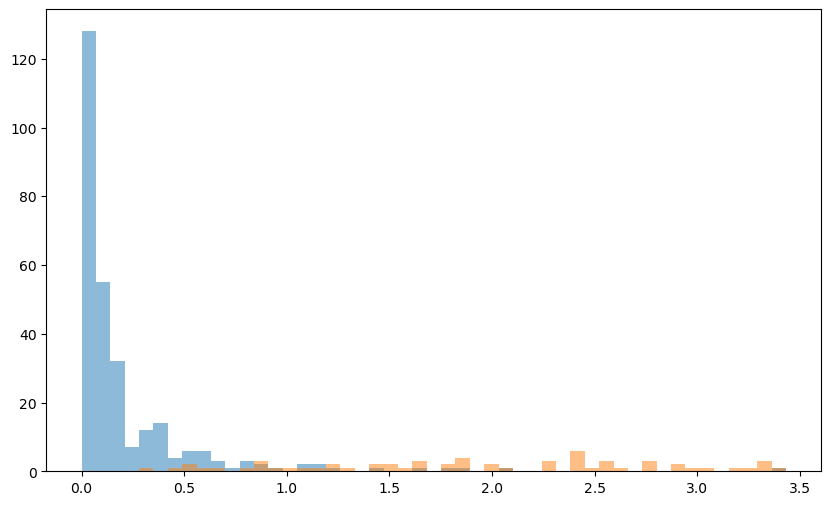

In [17]:
n_features = experimental_data.shape[0]
n_dim = 3

features = hkl_list
labels = experimental_data["intensity_exp"].tolist()
vol_err = experimental_data["intensity_exp_err"].tolist()


#labels = labels / np.max(labels) #Normalize labels
labels = labels / np.sum(labels) * 60  # Normalize to sum to 60

labels_err = []

for label, err in zip(labels, vol_err):
    if label == 0:
        labels_err.append(0.1)  # Assign a high error for zero labels
    else:
        labels_err.append(1/label)   # Normalize error to sum to 60
        #labels_err.append((500000 - (1/label * 1000))/1000)  # Inverse error for each label

labels_err = tf.convert_to_tensor(labels_err, dtype=tf.float32)
labels = tf.convert_to_tensor(labels, dtype=tf.float32)

labels = tf.expand_dims(labels, axis=-1)  # Ensure labels are 2D
labels_err = tf.expand_dims(labels_err, axis=-1)  # Ensure labels_err are 2D

print("Max label ERR:", np.max(labels_err))
print("min label ERR:", np.min(labels_err))
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)
print('error shape:', labels_err.shape)
print("Max label:", np.max(labels))
print("min label :", np.min(labels))
#bin from0 to 0.0025 with 50 bins
plt.figure(figsize=(10, 6))

plt.hist(labels.numpy(), bins=np.linspace(0 , np.max(labels) , 50), alpha=0.5, label='Labels')
plt.hist(labels_err.numpy(), bins=np.linspace(0 , np.max(labels) , 50), alpha=0.5, label='Labels Error')


In [18]:
def fun_tf(hkl_list, pars, matrix):
    """
    Fast computation of structure factors with parameter-dependent structure.
    """
    # stack parameters
    pars_tensor = tf.stack(pars)  # shape (params,)

    atom_shift_list = shift_atoms(matrix , (pars_tensor))
    atom_shift_list = atom_shift_list[:,0]
    atom_shift_list = tf.unstack(atom_shift_list)

    modified_struct = atom_position_list(*atom_shift_list)

    hkl_list = transform_list_hkl_p63_p65(hkl_list)

    # Get structure factors
    sf_hkl = get_structure_factors(hkl_list, modified_struct)
    intensity = (abs(sf_hkl)) ** 2

    w = tf.constant(0.000811509257682975, dtype=tf.float32)  # Debye-Waller factor 
    qnorms = tf.norm(tf.cast(hkl_list, tf.float32), axis=1)
    intensity = intensity * tf.exp(- w * qnorms ** 2)  # Apply Debye-Waller factor
    #intensity = tf.where(intensity < max_intensity * 0.01, tf.zeros_like(intensity), intensity)  # Ensure no negative intensities
    #intensity = log10(intensity + 1)  # Convert to log10 scale
    sim_intensity = intensity
    #sim_intensity = intensity / tf.reduce_max(intensity)  # Normalize to max intensity
    sim_intensity = sim_intensity / tf.reduce_sum(sim_intensity) * 60
    return sim_intensity



Define a simple model

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- The six parameters (a,b,c,d,e,f) correspond to the fractional atomic shifts in the modes w.r.t. unit cell lengths
- Instead of `sigmoid`, `tanh` should be applied to the parameters before passing them to the structure factor calculation function (ensures smoother gradient landscape)
- The `tanh` function can furthermore be limited to a specific range (e.g. if atomic distortions should not exceed +- 0.1)

In [19]:
class FunAsLayer(tf.keras.layers.Layer):
    def __init__(self, matrix , max_mode_amps,**kwargs):
        super().__init__(**kwargs)
        self.max_mode_amps = max_mode_amps
        self.matrix = matrix

    def build(self, input_shape):
        self.param = self.add_weight(name='param', shape=(mode_num,), initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.01, seed=1), trainable=True)
        super().build(input_shape)

    def call(self, inputs):
        # Apply tanh to ensure parameters stay within the [-1, 1] range then multiply by max_mode_amps so each parameter is scaled corresponding to the element in max_mode_amps
        pretransform = tf.tanh(self.param)
        transformed_params = pretransform * self.max_mode_amps  # Scale parameters

        output = fun_tf(inputs, transformed_params , self.matrix)
        return tf.reshape(output , [-1])  # Ensure output is 1D




Create optimizer and define loss function

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- The learning rate must be determined by experimentation (same holds for the batch size and the number of epochs below)
- As a loss function, one can try either MSE or R-score (MSE seems to be the more "natural choice" in this case)

In [20]:
"""
# R-Score based on intensity
class RFactorLoss(tf.keras.losses.Loss):
    def call(self, y_true, y_pred):
        return tf.reduce_sum(tf.abs(y_true - y_pred)) / tf.reduce_sum(y_true)
"""
    
# mean squared error
class PerSampleMSE(tf.keras.losses.Loss):
    def __init__(self):
        super().__init__(reduction=tf.keras.losses.Reduction.NONE)

    def call(self, y_true, y_pred):
        squared_error = tf.square(y_true - y_pred)
        per_sample_mse = tf.reduce_mean(squared_error, axis=-1)
        return per_sample_mse  # shape (batch_size,)

class WeightedMeanSquaredError(tf.keras.losses.Loss):
    def __init__(self,reduction=tf.keras.losses.Reduction.AUTO, name='WeightedMeanSquaredError'):
        super(WeightedMeanSquaredError, self).__init__(reduction=reduction, name=name)

    def call(self, y_true, y_pred):
        return tf.keras.losses.mean_squared_error(y_true, y_pred)

    def num_of_elements(self, sample_weight):
        return tf.size(sample_weight).numpy()
    
    def __call__(self, y_true, y_pred, sample_weight):
        #return super().__call__(y_true, y_pred, 1)
        # 1/n *  sum(weights * mse(y_p - y_t))
        actual_loss = super().__call__(y_true, y_pred, sample_weight)
        num_of_el = tf.py_function(func=self.num_of_elements, inp = [sample_weight], Tout=tf.float32)

        # dividing by sum of all weights in this batch
        # (sum(weights * mse(y_p - y_t))) / sum(weights)
        wmse_loss = actual_loss * (num_of_el / tf.math.reduce_sum(sample_weight))
        return wmse_loss
  

# Define the custom metric function
def r_factor_metric(y_true, y_pred):
    labels = y_true
    return tf.reduce_sum(tf.abs(labels - y_pred)) / tf.reduce_sum(tf.abs(labels))


Train the model for n iterations (to try different initial weights)

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- The number of iterations defines the "starting position" $w_0$ of the gradient descent algorithm
- Because there are probably many local minima, changing $w_0$ allows the algorithm to find different minima and increases the chances of finding the global minima

Learning rate: 0.001
Epoch 1/500
1/1 [==============================] - 3s 3s/step - loss: 0.1789 - r_factor_metric: 1.0833
Epoch 2/500
1/1 [==============================] - 0s 5ms/step - loss: 0.1695 - r_factor_metric: 1.0476
Epoch 3/500
1/1 [==============================] - 0s 17ms/step - loss: 0.1595 - r_factor_metric: 1.0122
Epoch 4/500
1/1 [==============================] - 0s 4ms/step - loss: 0.1500 - r_factor_metric: 0.9831
Epoch 5/500
1/1 [==============================] - 0s 7ms/step - loss: 0.1420 - r_factor_metric: 0.9663
Epoch 6/500
1/1 [==============================] - 0s 5ms/step - loss: 0.1366 - r_factor_metric: 0.9648
Epoch 7/500
1/1 [==============================] - 0s 7ms/step - loss: 0.1342 - r_factor_metric: 0.9699
Epoch 8/500
1/1 [==============================] - 0s 6ms/step - loss: 0.1340 - r_factor_metric: 0.9808
Epoch 9/500
1/1 [==============================] - 0s 7ms/step - loss: 0.1346 - r_factor_metric: 0.9889
Epoch 10/500
1/1 [=========================

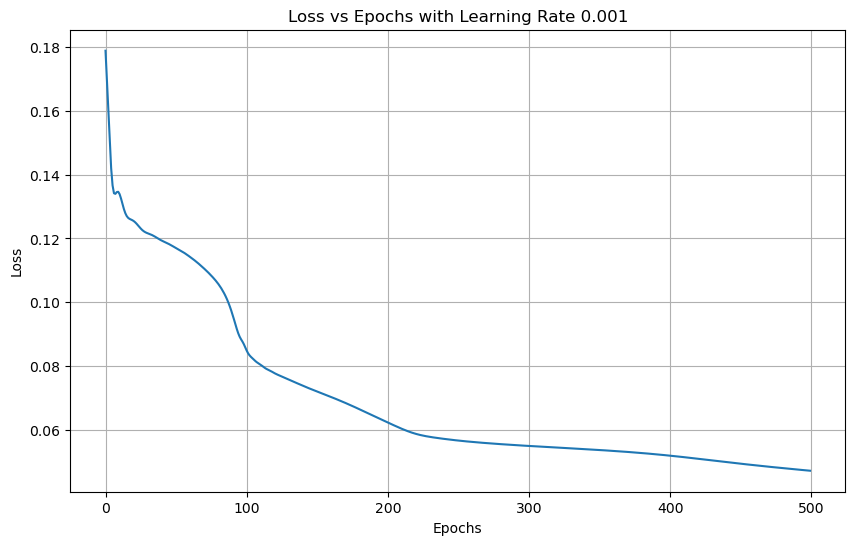

Best R-factor for learning rate 0.001: 7.003e-01


In [27]:
lr = [1e-3]
best_pars_overall = None
best_rf_overall = np.inf
best_loss_overall = []

for learning_rate in lr:
    time_start = time()
    print(f"Learning rate: {learning_rate}")
    optim = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    path_max_mode_amps = path + '/PBCO_1_3_' + structure_type + '_max_bound_vectors.txt'
    max_mode_amps = np.loadtxt(path_max_mode_amps, dtype=np.float32 , delimiter=',')

    max_mode_amps = tf.convert_to_tensor(max_mode_amps, dtype=tf.float32)

    n_epochs = 500
    histories = []
    n_iter = 1

    min_loss = np.inf
    best_pars = None
    # List to store the loss values for each epoch
    all_losses = []

    for i in range(n_iter):
        # Create the model
        inputs = tf.keras.Input(shape=(n_dim,))
        outputs = FunAsLayer(matrix , max_mode_amps)(inputs)
        model = tf.keras.Model(inputs, outputs)

        initial_weights = model.layers[-1].get_weights()[0]

        # Compile the model with the custom loss function and metric
        model.compile(
            optimizer=optim,
            loss= WeightedMeanSquaredError(), # MSE_weighted() if using errors
            metrics=[r_factor_metric],
            run_eagerly=False,  # Set to True for debugging, False for performance

        )
        
        history = model.fit(
        x=features,
        y=labels,  # replace with combined_labels if using errors
        batch_size = features.shape[0], # Use a smaller batch size features.shape[0]
        epochs=n_epochs,
        verbose='auto',
        shuffle=True, # not sure whether this matters
        # callbacks=[cb]
        sample_weight=labels_err  # Use sample weights if you have errors
        )

        histories.append(history)
        all_losses.append(history.history['loss'])
        # Check final loss
        final_loss = history.history['loss'][-1]
        print(model.layers[-1].get_weights()[0].shape)
        curren_model_pars = max_mode_amps * tf.tanh(model.layers[-1].get_weights()[0])

        print(f"Final loss: {final_loss:.3e}")

        if final_loss < min_loss:
            # Update best model parameters
            best_model_pars = max_mode_amps * tf.tanh(model.layers[-1].get_weights()[0])
            min_loss = final_loss
            rf = r_factor_metric(labels, fun_tf(features, best_model_pars , matrix))
            print(f"Iteration {i+1} - New best loss: {min_loss:.3e} (R-factor: {rf:.3e})")

    if min_loss < best_rf_overall:
        best_rf_overall = min_loss
        best_pars_overall = best_model_pars
        best_loss_overall = all_losses
    print(f"time elapsed: {time() - time_start:.2f} seconds")
    print(f"With {n_epochs*n_iter /(time() - time_start)} iterations per second")
    # Plotting the loss values
    plt.figure(figsize=(10, 6))

    # Plot the loss values for each iteration
    for i, loss_values in enumerate(all_losses):
        plt.plot(loss_values, label=f'Iteration {i+1}')

    plt.title(f'Loss vs Epochs with Learning Rate {learning_rate}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    # plt.legend()
    plt.grid(True)
    plt.show()

    y_pred = fun_tf(features, best_model_pars , matrix)
    labels = tf.reshape(labels, [-1])
    rf = r_factor_metric(labels, y_pred)
    print(f"Best R-factor for learning rate {learning_rate}: {rf:.3e}")
    final_weights = model.layers[-1].get_weights()[0]

min loss: 0.04718019440770149
r_factor: 0.7002652287483215


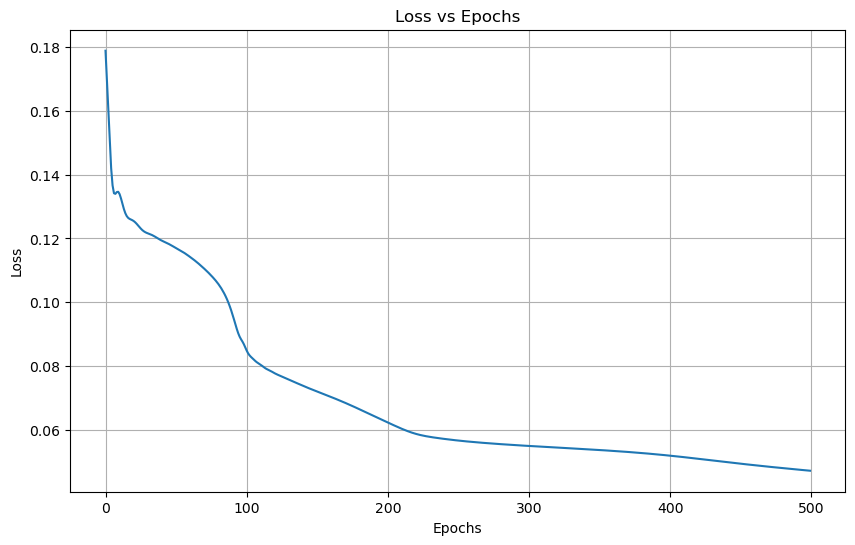

In [28]:
all_losses = best_loss_overall
best_model_pars = best_pars_overall
min_loss = best_rf_overall

print(f"min loss: {min_loss}")
print(f"r_factor: {rf}")

# Plotting the loss values
plt.figure(figsize=(10, 6))

# Plot the loss values for each iteration
for i, loss_values in enumerate(all_losses):
    plt.plot(loss_values, label=f'Iteration {i+1}')

plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# plt.legend()
plt.grid(True)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_19848\967692745.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)


Best model parameters:
mode a1 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a) : 0.01852634
mode a2 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a) : 0.00213023
mode a3 Pmmm[0,1/3,0]DT1(a,0)[Pr1:h:dsp]B2u(a) : 0.03159872
mode a4 Pmmm[1/3,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a) : -0.00218218
mode a5 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]A1(a) : 0.13913891
mode a6 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B2(a) : 0.00046259
mode a7 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B1(a) : -0.00677872
mode a8 Pmmm[0,0,0]GM1+(a)[Ba1:t:dsp]A1(a) : nan
mode a9 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]A1(a) : -0.02295152
mode a10 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]B2(a) : -0.01495494
mode a11 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]A1(a) : -0.00424417
mode a12 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]B1(a) : -0.00964984
mode a13 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B3u(a) : -0.04844206
mode a14 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B2u(a) : 0.08026560
mode a15 Pmmm[0,1/3,0]DT1(a,0)[Cu1:a:dsp]B2u(a) : -0.01519148
mode a16 Pmmm[1/3,0,0]SM1(a,0)[Cu1:a:dsp]B3u(a

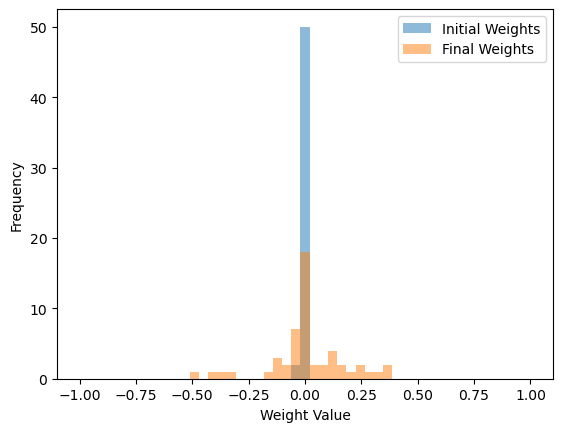

In [29]:
path_displacive_modes = path + '/PBCO_1_3_' + structure_type + '_displacive_modes.txt'

mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)
mode_names = mode_names.values.tolist()
mode_names = pd.DataFrame(mode_names)

# Print the best model parameters
print("Best model parameters:") 
for i, par in enumerate(best_model_pars):
    print(f"mode a{i+1} {mode_names.iloc[i, 1]} : {par.numpy()/max_mode_amps[i]:.8f}")

plt.hist(initial_weights, bins=np.linspace(-1 , 1 , 50), alpha=0.5, label='Initial Weights')
plt.hist(final_weights, bins=np.linspace(-1 , 1 , 50), alpha=0.5, label='Final Weights')
plt.xlabel('Weight Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [30]:

def alris_r_factor(data):
    exp_intensity = data['intensity_exp'] / np.max(data['intensity_exp'])
    exp_intensity = exp_intensity / np.sum(exp_intensity) * 60
    simulated_intensity = data['intensity_sim']
    alris_r_factor = np.sum(np.abs(exp_intensity - simulated_intensity)) / np.sum(np.abs(exp_intensity))
    return alris_r_factor

def plot_plane_sim_vs_exp_DIM1(ax, df, r_factor, norm_plane=False):
    exp_data_0 = df.loc[df['h'] == 0].copy()
    if norm_plane:
        exp_data_0['intensity_exp'] = exp_data_0['intensity_exp'] / np.sum(exp_data_0['intensity_exp']) * 60
    
    ax.scatter(exp_data_0['k'], exp_data_0['l'], 
               s=np.log10(exp_data_0['intensity_sim'] + 1)* 500 , color='red', edgecolor= None,
               label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    ax.scatter(exp_data_0['k'] , exp_data_0['l'] , s=np.log10(exp_data_0['intensity_exp'] + 1)* 500 , color='blue', edgecolor="black",
               label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    ax.set_xlabel(f"k in (0, k, l) [r.l.u.]")
    ax.set_ylabel(f"l in (h, 0, l) [r.l.u.]")
    ax.set_title(f"KL plane for H = 0 (logged) , r-factor: {r_factor:.3f}")
    ax.legend()

def plot_plane_sim_vs_exp_DIM2(ax, df,r_factor, norm_plane=False):
    exp_data_0 = df.loc[df['k'] == 0].copy()
    if norm_plane:
        exp_data_0['intensity_exp'] = exp_data_0['intensity_exp'] / np.sum(exp_data_0['intensity_exp']) * 60
    
    ax.scatter(exp_data_0['h'], exp_data_0['l'], 
               s=np.log10(exp_data_0['intensity_sim'] + 1) * 500 , color='red', edgecolor="black",
               label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    ax.scatter(exp_data_0['h'] , exp_data_0['l'] , s=np.log10(exp_data_0['intensity_exp'] + 1) * 500, color='blue', edgecolor="black",
               label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    ax.set_xlabel(f"h in (h, 0, l) [r.l.u.]")
    ax.set_ylabel(f"l in (h, 0, l) [r.l.u.]")
    ax.set_title(f"HL plane for K = 0 (logged) , r-factor: {r_factor:.3f}")
    ax.legend()

def plot_plane_sim_vs_exp_DIM3(ax, df, r_factor, l, norm_plane=False):
    exp_data_0 = df.loc[df['l'] == l].copy()
    if norm_plane:
        exp_data_0['intensity_exp'] = exp_data_0['intensity_exp'] / np.sum(exp_data_0['intensity_exp']) * 60
    
    ax.scatter(exp_data_0['h'], exp_data_0['k'], 
            s=np.log10(exp_data_0['intensity_sim'] + 1)* 500 , color='red', edgecolor="black",
            label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    ax.scatter(exp_data_0['h'] , exp_data_0['k'] , s=np.log10(exp_data_0['intensity_exp'] + 1)* 500 , color='blue', edgecolor="black",
            label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    ax.set_xlabel(f"h in (h, k, {l}) [r.l.u.]")
    ax.set_ylabel(f"k in (h, k, {l}) [r.l.u.]")
    ax.set_title(f"HK plane for L = {l} (logged) , r-factor: {r_factor:.3f}")
    ax.legend()

ALRIS R-factor: 0.700


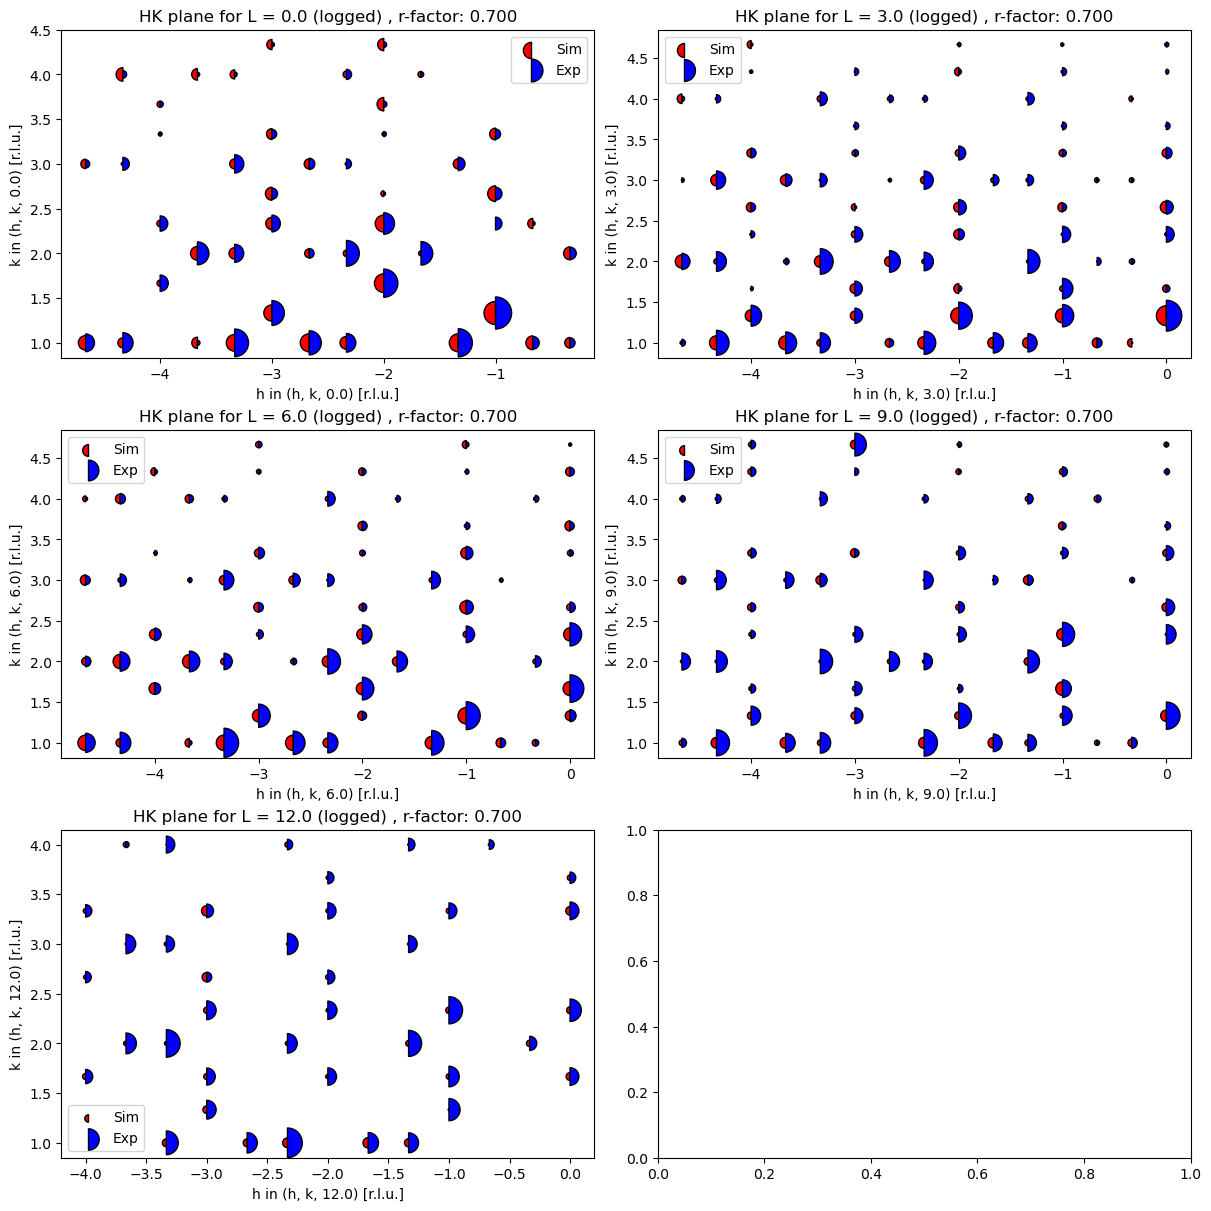

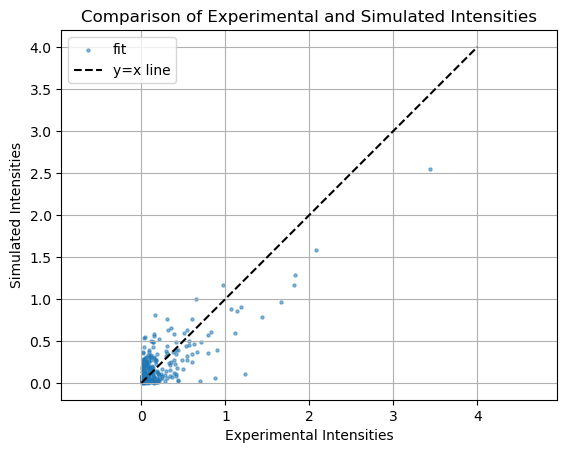

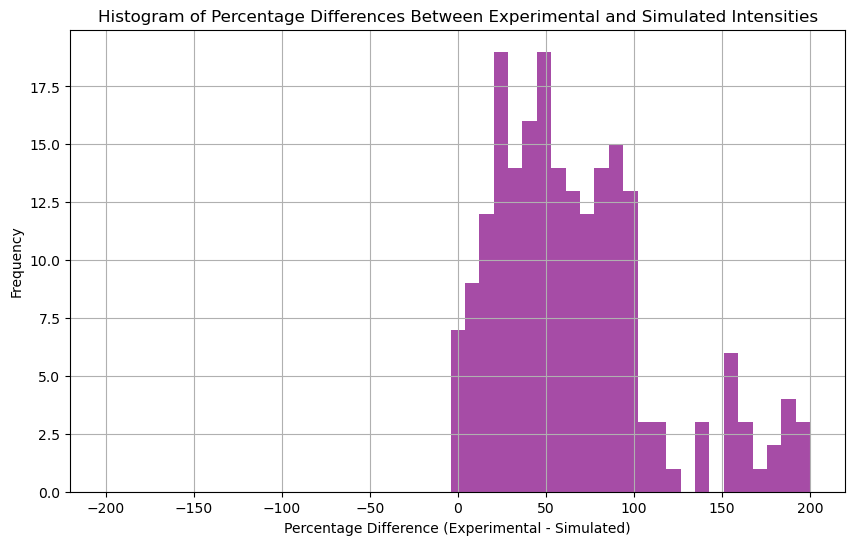

In [31]:
exp_data = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/1_3_combined_peaks_300K_no0.csv')
exp_data['intensity_sim'] = fun_tf(features, best_model_pars, matrix).numpy()
r_factor = alris_r_factor(exp_data)
print(f"ALRIS R-factor: {r_factor:.3f}")

normalised_exp_data = exp_data['intensity_exp'] / np.sum(exp_data['intensity_exp']) * 60
exp_data['normalised_intensity_exp'] = normalised_exp_data
exp_data['intensity_exp_err'] = labels_err.numpy()

l_values = [0.0, 3.0, 6.0, 9.0, 12.0]

n = len(l_values)
ncols = int(np.ceil(n / 3))
fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
axs = axs.flatten()

for i, l in enumerate(l_values):
    plot_plane_sim_vs_exp_DIM3(axs[i], exp_data, r_factor,l, norm_plane=True)

plt.show()

normalised_exp = exp_data['intensity_exp']/np.sum(exp_data['intensity_exp']) * 60

x = np.linspace(0 ,4, 100)
y = x
plt.scatter(normalised_exp, exp_data['intensity_sim'], s=5, alpha=0.5 , label='fit')
plt.plot(x , y, color='black', linestyle='--', label='y=x line')
plt.legend()
plt.grid(True)
plt.title('Comparison of Experimental and Simulated Intensities')
plt.xlabel('Experimental Intensities')
plt.ylabel('Simulated Intensities')
plt.axis('equal')
plt.show()


#plot a historgram of the percentage difference in intensity between experimental and simulated
percentage_diff = np.abs(normalised_exp - exp_data['intensity_sim']) / normalised_exp * 100
exp_data['percentage_diff'] = percentage_diff
plt.figure(figsize=(10, 6))
plt.hist(percentage_diff, bins=np.linspace(-200 , 200 , 50), alpha=0.7, color='purple')
plt.title('Histogram of Percentage Differences Between Experimental and Simulated Intensities')
plt.xlabel('Percentage Difference (Experimental - Simulated)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [16]:
#save the experiment data with simulated intensities
exp_data.to_csv('C:/Users/User/Desktop/uzh_intern/CrystalClearFit/alrisDistortionFit/PBCO/fitted_data/peaks_with_simulated_intensities.txt', index=False)

#save all the parameters and the modes
with open('C:/Users/User/Desktop/uzh_intern/CrystalClearFit/alrisDistortionFit/PBCO/fitted_data/parameters_and_modes.txt', 'w') as f:
    f.write(f"final loss: {min_loss:.8f}\n")
    f.write(f"Number of iterations: {n_iter}\n")
    f.write(f"r_factor: {r_factor:.8f}\n")
    f.write(f"learning_rate: {lr[0]:.8f}\n")
    f.write(f"n_epochs: {n_epochs}\n")
    f.write(f"Best model parameters:\n")
    for i, par in enumerate(best_model_pars):
        f.write(f"{mode_names.iloc[i, 1]} : {par.numpy():.8f} \n")

abs_params = tf.abs(best_model_pars)
best_model_pars_compare = best_model_pars.numpy()
best_model_pars_compare = best_model_pars_compare / np.max(best_model_pars_compare)

#save all the parameters and the modes
with open('C:/Users/User/Desktop/uzh_intern/CrystalClearFit/alrisDistortionFit/PBCO/fitted_data/parameters_and_modes_normalised.txt', 'w') as f:
    f.write(f"final loss: {min_loss:.8f}\n")
    f.write(f"learning_rate: {lr[0]:.8f}\n")
    f.write(f"n_epochs: {n_epochs}\n")
    f.write(f"Best model parameters:\n")
    for i, par in enumerate(best_model_pars_compare):
        f.write(f"{mode_names.iloc[i, 1]} : {par:.8f} \n")



In [17]:
best_data = pd.read_csv('C:/Users/User/Desktop/uzh_intern/CrystalClearFit/alrisDistortionFit/fitted_data/peaks_with_simulated_intensities.txt')

fig, axs = plt.subplots(1, 2, figsize=(24, 12), constrained_layout=True)
plot_plane_sim_vs_exp(axs[0], best_data, 0, norm_plane=True)
plot_plane_sim_vs_exp(axs[1], exp_data, 0, norm_plane=True)

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/User/Desktop/uzh_intern/CrystalClearFit/alrisDistortionFit/fitted_data/peaks_with_simulated_intensities.txt'